# Préparation des données Parcoursup

Ce bloc prépare une base propre avant l'analyse uni-dimensionnelle :
- chargement des données,
- sélection des variables utiles,
- création d'indicateurs simples et interprétables pour l'analyse.


In [ ]:
library(tidyverse)

# Lecture du CSV Parcoursup (sep=';' car format français, check.names pour noms exploitables en R)
data <- read.csv('Parcoursup.csv', sep = ';', header = TRUE, stringsAsFactors = FALSE, check.names = TRUE)

# Contrôle minimal : nombre de lignes/colonnes + aperçu de 3 lignes
dim(data)
head(data, 3)


## Vérification rapide

On vérifie la structure globale sans multiplier les diagnostics : dimensions, types et quelques statistiques de base.


In [ ]:
# Vue d'ensemble des types de variables (numériques, caractères, etc.)
glimpse(data)

# Résumé ciblé sur des variables de volume utiles pour la suite
summary(select(data,
  Capacité.de.l.établissement.par.formation,
  Effectif.total.des.candidats.pour.une.formation,
  Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis.
))


## Nettoyage et variables construites

Logique du nettoyage :
- retirer les colonnes techniques ou trop fines pour l'objectif (identifiants, GPS, liens, détails redondants),
- conserver les colonnes utiles à l'analyse genre/sélectivité/profil des admis,
- construire des variables agrégées simples (2 phases, pourcentages de genre, parts de mentions).


In [ ]:
# Colonnes retirées : identifiants techniques, géographie trop fine, détails redondants
cols_to_drop <- c(
  'Session',
  'Code.UAI.de.l.établissement',
  'Code.départemental.de.l.établissement',
  'Département.de.l.établissement',
  'Coordonnées.GPS.de.la.formation',
  'Commune.de.l.établissement',
  'Filière.de.formation.détaillée',
  'Filière.de.formation.détaillée.bis',
  'Filière.de.formation.très.détaillée',
  'Dont.effectif.des.candidats.ayant.postulé.en.internat',
  'Effectif.total.des.candidats.classés.par.l.établissement.en.phase.principale',
  'Effectif.des.candidats.classés.par.l.établissement.en.phase.complémentaire',
  'Effectif.des.candidats.classés.par.l.établissement.en.internat..CPGE.',
  'Effectif.des.candidats.classés.par.l.établissement.hors.internat..CPGE.',
  'Concours.communs.et.banque.d.épreuves',
  'cod_aff_form',
  'Lien.de.la.formation.sur.la.plateforme.Parcoursup',
  'etablissement_id_paysage',
  'composante_id_paysage'
)

# any_of : évite une erreur si une colonne listée est absente
data <- data %>%
  select(-any_of(cols_to_drop))

# Colonnes converties en numérique avant calcul de ratios
num_cols <- c(
  'Capacité.de.l.établissement.par.formation',
  'Effectif.total.des.candidats.en.phase.principale',
  'Effectif.total.des.candidats.en.phase.complémentaire',
  'Effectif.des.admis.en.phase.principale',
  'Effectif.des.admis.en.phase.complémentaire',
  'Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis.',
  'Dont.effectif.des.candidates.admises',
  'Effectif.des.admis.néo.bacheliers',
  'Dont.effectif.des.admis.néo.bacheliers.sans.mention.au.bac',
  'Dont.effectif.des.admis.néo.bacheliers.avec.mention.Assez.Bien.au.bac',
  'Dont.effectif.des.admis.néo.bacheliers.avec.mention.Bien.au.bac',
  'Dont.effectif.des.admis.néo.bacheliers.avec.mention.Très.Bien.au.bac',
  'Dont.effectif.des.admis.néo.bacheliers.avec.mention.Très.Bien.avec.félicitations.au.bac'
)

data <- data %>%
  # across(...): applique as.numeric à toutes les colonnes de num_cols
  mutate(across(any_of(num_cols), ~ suppressWarnings(as.numeric(.x)))) %>%
  mutate(
    # Agrégation des volumes sur les deux phases d'admission
    Effectif.total.candidats.2phases = coalesce(Effectif.total.des.candidats.en.phase.principale, 0) +
      coalesce(Effectif.total.des.candidats.en.phase.complémentaire, 0),
    Effectif.total.admis.2phases = coalesce(Effectif.des.admis.en.phase.principale, 0) +
      coalesce(Effectif.des.admis.en.phase.complémentaire, 0),

    # Parts filles/garçons parmi les admis (entre 0 et 1)
    pct_filles_admises = if_else(
      Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis. > 0,
      Dont.effectif.des.candidates.admises / Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis.,
      NA_real_
    ),
    pct_garcons_admis = if_else(!is.na(pct_filles_admises), 1 - pct_filles_admises, NA_real_),

    # Parts de mentions parmi les admis néo-bacheliers
    part_mention_ab = if_else(Effectif.des.admis.néo.bacheliers > 0,
      Dont.effectif.des.admis.néo.bacheliers.avec.mention.Assez.Bien.au.bac / Effectif.des.admis.néo.bacheliers, NA_real_),
    part_mention_b = if_else(Effectif.des.admis.néo.bacheliers > 0,
      Dont.effectif.des.admis.néo.bacheliers.avec.mention.Bien.au.bac / Effectif.des.admis.néo.bacheliers, NA_real_),
    part_mention_tb = if_else(Effectif.des.admis.néo.bacheliers > 0,
      Dont.effectif.des.admis.néo.bacheliers.avec.mention.Très.Bien.au.bac / Effectif.des.admis.néo.bacheliers, NA_real_),
    part_mention_tb_fel = if_else(Effectif.des.admis.néo.bacheliers > 0,
      Dont.effectif.des.admis.néo.bacheliers.avec.mention.Très.Bien.avec.félicitations.au.bac / Effectif.des.admis.néo.bacheliers, NA_real_)
  )


## Features principales pour l'analyse

On crée un jeu de features simple et cohérent avec le cours : ratios interprétables, transformations log des volumes et discrétisation par quantiles.


In [ ]:
# Conversion de Taux.d.accès (texte) en proportion numérique [0,1]
data <- data %>%
  mutate(
    taux_acces_num = suppressWarnings(as.numeric(gsub(',', '.', gsub('%', '', Taux.d.accès)))) / 100
  )

data_features_core <- data %>%
  mutate(
    # Intensité de la demande vs places disponibles
    pression_candidature = if_else(Capacité.de.l.établissement.par.formation > 0,
      Effectif.total.candidats.2phases / Capacité.de.l.établissement.par.formation, NA_real_),

    # Probabilité d'être admis parmi les candidats
    taux_admission = if_else(Effectif.total.candidats.2phases > 0,
      Effectif.total.admis.2phases / Effectif.total.candidats.2phases, NA_real_),

    # Niveau de remplissage de la capacité
    taux_remplissage = if_else(Capacité.de.l.établissement.par.formation > 0,
      Effectif.total.admis.2phases / Capacité.de.l.établissement.par.formation, NA_real_),

    # Regroupement des meilleures mentions
    part_mention_haute = part_mention_tb + part_mention_tb_fel,

    # Score synthétique (pondération croissante avec le niveau de mention)
    score_mention = 1 * coalesce(part_mention_ab, 0) +
      2 * coalesce(part_mention_b, 0) +
      3 * coalesce(part_mention_tb, 0) +
      4 * coalesce(part_mention_tb_fel, 0),

    # log1p stabilise les variables de volume très asymétriques
    log_candidats = log1p(Effectif.total.candidats.2phases),
    log_admis = log1p(Effectif.total.admis.2phases),
    log_capacite = log1p(Capacité.de.l.établissement.par.formation),

    # Discrétisation en quartiles (1 = faible, 4 = élevé)
    pression_q = ntile(pression_candidature, 4),
    taux_acces_q = ntile(taux_acces_num, 4)
  ) %>%
  # Sélection du sous-ensemble de variables pour l'analyse
  select(
    Établissement, Filière.de.formation, Filière.de.formation.très.agrégée,
    Région.de.l.établissement, Académie.de.l.établissement, Sélectivité,
    pct_filles_admises, pct_garcons_admis,
    pression_candidature, taux_admission, taux_remplissage, taux_acces_num,
    part_mention_ab, part_mention_b, part_mention_tb, part_mention_tb_fel, part_mention_haute, score_mention,
    log_candidats, log_admis, log_capacite,
    pression_q, taux_acces_q
  )

# Vérification rapide du jeu de features final
glimpse(data_features_core)
summary(select(data_features_core, where(is.numeric)))


# Analyse uni-dimensionnelle des variables

Autre formation               BTS               BUT              CPGE 
             1815              5351               820               986 
Ecole d'Ingénieur Ecole de Commerce              EFTS              IFSI 
              585               256               243               344 
          Licence       Licence_Las              PASS 
             3052               513               287

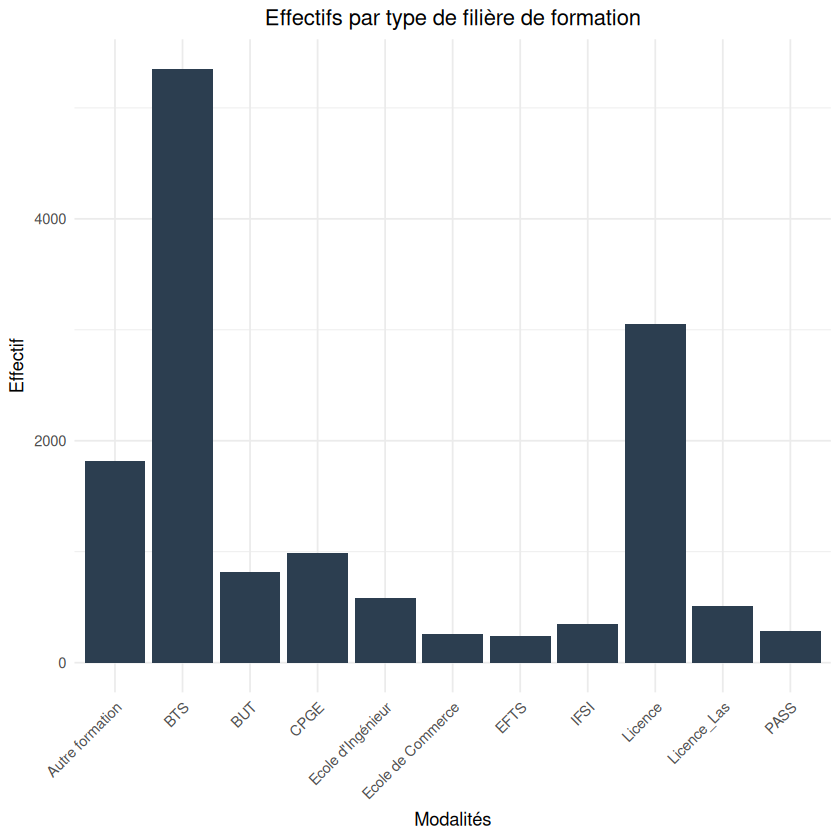

In [19]:
summary(data$`Filière.de.formation.très.agrégée`)
library(ggplot2)

ggplot(data, aes(x = `Filière.de.formation.très.agrégée`)) +
  geom_bar(fill = "#2C3E50") +
  labs(
    title = "Effectifs par type de filière de formation",
    x = "Modalités",
    y = "Effectif"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

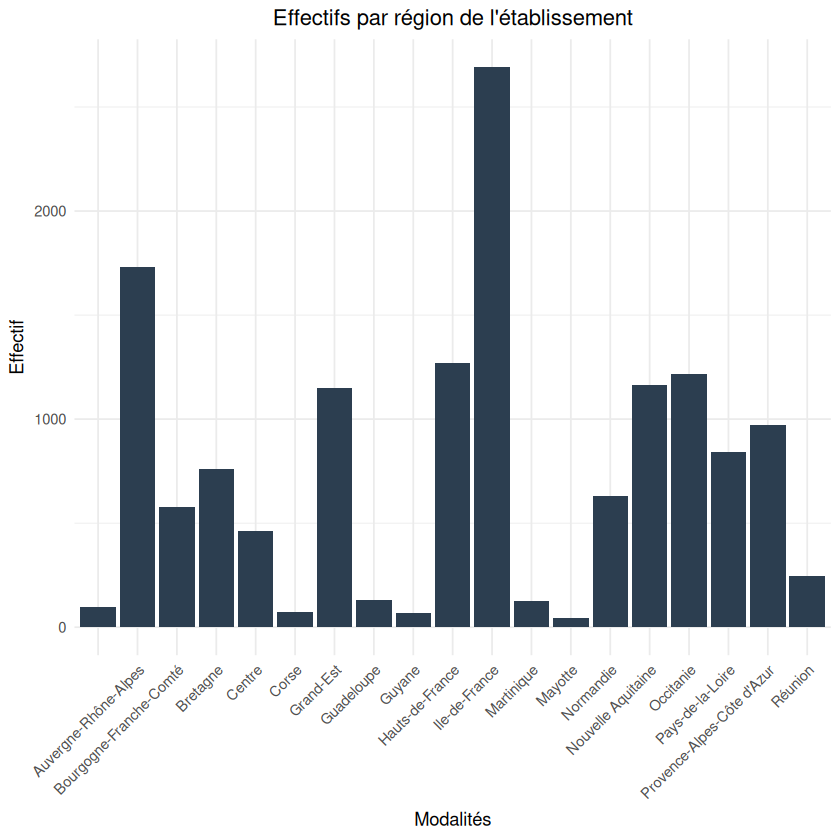

In [20]:
ggplot(data, aes(x = Région.de.l.établissement)) +
  geom_bar(fill = "#2C3E50") +
  labs(
    title = "Effectifs par région de l'établissement",
    x = "Modalités",
    y = "Effectif"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )